In [1]:
import allel
print("allel:",allel.__version__)
import numpy as np
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

allel: 1.3.5
numpy: 1.21.6


In [2]:
from plotnine import *

In [3]:
#vcf='phased_shapeit_1_200samples.vcf.gz'
vcf='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr3.vcf.gz'
#vcf='resources/Aaeg1200g/aegy.wgs.aaa.aaf.mapQ20.GoodSites.chr3.SNP.refseq.7e6.phased.vcf.gz'
#vcf='resources/Aaeg1200g/shapeit.kdr3.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'

pop1='USA'

#chrom=2
#locus=[94761102,95559560]

chrom=3
locus=[315926360,316405639]

In [4]:
meta = pd.read_csv(metafile, sep='\t')
poplevel = 'country'

In [5]:
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')

pops, popn = np.unique(meta['pop'][meta[poplevel]==pop1], return_counts=True)
pd.DataFrame({"pop":pops,
              "popn":popn})

,pop,popn
0,Clovis,16
1,Coachella,19
2,LasCruces,18
3,LosAngeles,20
4,MaricopaCounty,23
5,Miami,15
6,NewOrleans,15
7,Roswell,19


In [101]:
pop1=pops[7]
pop1samps = meta['sample'][meta['pop']==pop1]
callset1 = allel.read_vcf(vcf, samples=pop1samps, fields=['calldata/GT','variants/POS'])
gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
gtpop1

<GenotypeArray shape=(2448555, 19, 2) dtype=int8>
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/0 0/0 0/0
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/0 0/0 0/0
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/0 0/0 0/0
...
0/0 0/0 1/0 0/0 1/0 ... 0/1 0/1 0/0 0/0 1/1
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/0 0/0 0/0
0/0 0/0 0/1 0/0 0/0 ... 0/0 0/1 0/0 0/0 0/1

In [102]:
ac1 = gtpop1.count_alleles()


In [112]:
np.min(ac1,1)

array([0, 0, 0, ..., 9, 0, 5], dtype=int32)

In [103]:
sum(np.min(ac1,1)==0 )


1684764

In [120]:
def geth12wins(haparray,posns):
    
    h12wins = pd.DataFrame(columns = ["pop","win","chr","pos","h1","h12","h123","h2_h1"])

    for blen in [5,10,20,50,100,250,500]:
        bstep=round(blen/3)
        h1, h12, h123, h2_h1 = allel.moving_garud_h(haparray, blen, start=0, stop=None, step=bstep)

        print('{} {}'.format(blen,np.mean(h12)),file=sys.stderr)

        winposns = allel.moving_statistic(posns, np.average, blen, step=bstep)
        npos = winposns.size

        newdf = pd.DataFrame(data={"pop"  :[pop1]*npos,
                                   "win"  :[blen]*npos,
                                   "chr"  :[chrom]*npos,
                                   "pos"  :winposns,
                                   "h1"   :h1,
                                   "h12"  :h12,
                                   "h123" :h123,
                                   "h2_h1":h2_h1},
                     columns=["pop","win","chr","pos","h1","h12","h123","h2_h1"])
        h12wins = h12wins.append(newdf)
    return h12wins

5 0.5889759920473355
10 0.36995050421596776
20 0.20850889070219503
50 0.08025906683357291
100 0.03970107328601183
250 0.02821103817897146
500 0.027712951274777586


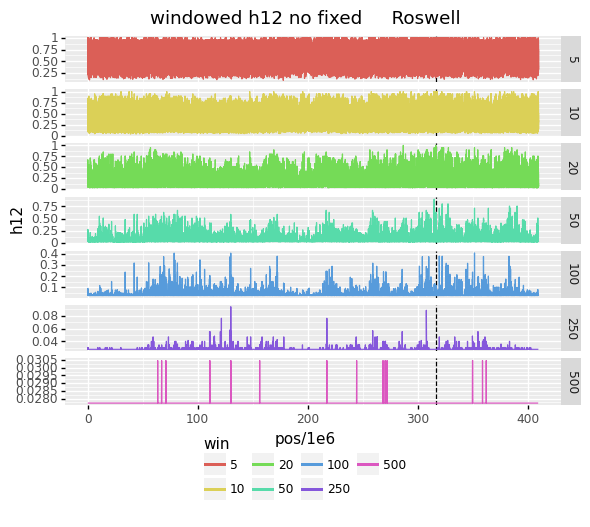

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 300.0 x 125.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_Roswell_kdr3_winsizes_nofixed.png


In [124]:
posns = callset1['variants/POS']
nonfixed = np.min(ac1,1) >=1
gtpopns = gtpop1[nonfixed,]
posns = posns[nonfixed]

hppop1 = gtpopns.to_haplotypes()

h12wins = geth12wins(hppop1,posns)       

p = ggplot(h12wins,aes(x='pos/1e6',y="h12",color="win")) + \
  geom_vline(xintercept=[np.mean(locus)/1e6],linetype="dashed") +\
  geom_line() + \
  ggtitle("windowed h12 no fixed     {p1}".format(p1=pop1)) + \
  theme(legend_position="bottom") + facet_grid(("win","."),scales="free_y")
print(p)
ggsave(plot=p, width=300,height=125,units='mm', filename='h12_{}_kdr3_winsizes_nofixed.png'.format(pop1), dpi=400)


5 0.5221064575894249
10 0.31655795047554897
20 0.17426213117847722
50 0.06523578834959692
100 0.034964241444322745
250 0.027921381411581993
500 0.027707569064909794


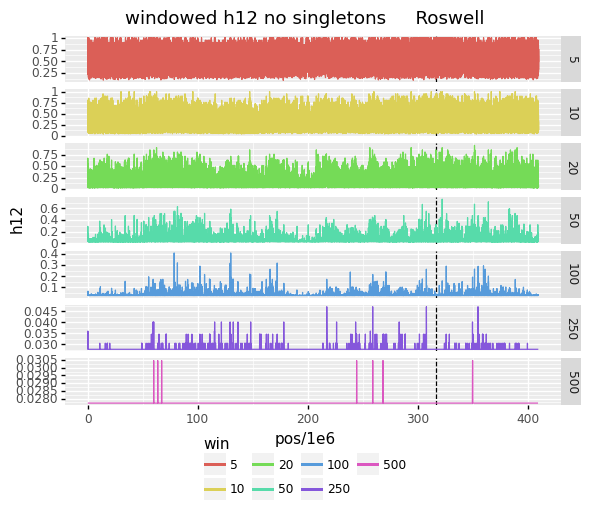

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 300.0 x 125.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_Roswell_kdr3_winsizes_nosing.png


In [123]:
posns = callset1['variants/POS']
nonsing = np.min(ac1,1) >=2
gtpopns = gtpop1[nonsing,]
posns = posns[nonsing]

hppop1 = gtpopns.to_haplotypes()

h12wins = geth12wins(hppop1,posns)       

p = ggplot(h12wins,aes(x='pos/1e6',y="h12",color="win")) + \
  geom_vline(xintercept=[np.mean(locus)/1e6],linetype="dashed") +\
  geom_line() + \
  ggtitle("windowed h12 no singletons     {p1}".format(p1=pop1)) + \
  theme(legend_position="bottom") + facet_grid(("win","."),scales="free_y")
print(p)
ggsave(plot=p, width=300,height=125,units='mm', filename='h12_{}_kdr3_winsizes_nosing.png'.format(pop1), dpi=400)


In [127]:
h12tab = pd.DataFrame(columns = ["pop","chr","pos","h1","h12","h123","h2_h1"])
posns = None
npos  = -1

blen=250
bstep=100

#region='NC_035109.1:300000000-320000000'
for pop2 in pops:
    pop1samps = meta['sample'][meta['pop']==pop2]
    callset1 = allel.read_vcf(vcf, 
 #                             region=region,
                              samples=pop1samps, 
                              fields=['calldata/GT','variants/POS'])
    
    if npos<0:
        posns = allel.moving_statistic(callset1['variants/POS'], np.average, blen, step=bstep)
        npos = posns.size
    gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
    hppop1 = gtpop1.to_haplotypes()
    
    print(pop2, file=sys.stderr)
    #get h12 values in windows
    h1, h12, h123, h2_h1 = allel.moving_garud_h(hppop1, blen, start=0, stop=None, step=bstep)
    
    newdf = pd.DataFrame(data={"pop"  :[pop2]*npos,
                               "chr"  :[chrom]*npos,
                               "pos"  :posns,
                               "h1"   :h1,
                               "h12"  :h12,
                               "h123" :h123,
                               "h2_h1":h2_h1},
                 columns=["pop","chr","pos","h1","h12","h123","h2_h1"])
    h12tab = h12tab.append(newdf)
    

Clovis
Coachella
Las_Cruces
Los_Angeles
Maricopa_County
Miami
New_Orleans
Roswell


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 300.0 x 125.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_250bp_kdr3_thinLD.png


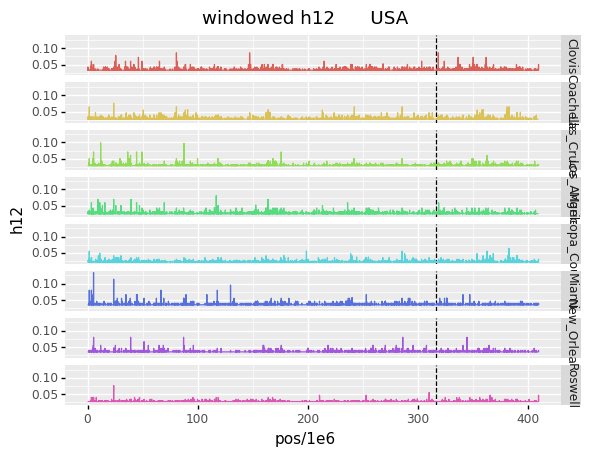

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 300.0 x 125.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_250bp_kdr3_thinLD_region.png
/opt/miniconda3/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 23009 rows containing missing values.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 23009 rows containing missing values.


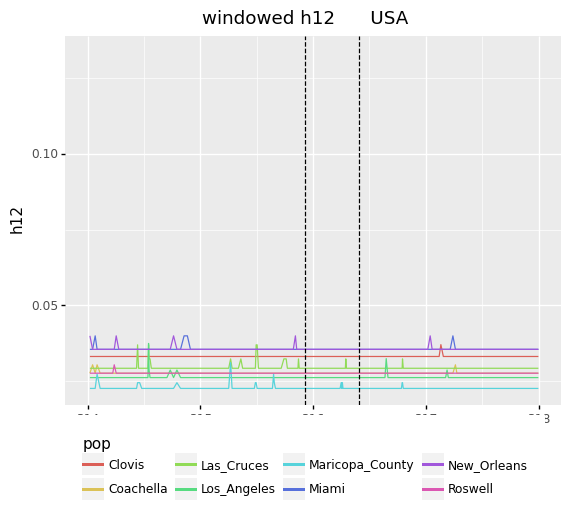

In [128]:
p = ggplot(h12tab,aes(x='pos/1e6',y="h12",color="pop")) + \
  geom_vline(xintercept=[np.mean(locus)/1e6],linetype="dashed") +\
  geom_line() + \
  ggtitle("windowed h12      {p1}".format(p1=pop1)) +\
  theme(legend_position='bottom') + facet_grid(("pop",".")) +\
  scale_color_discrete(guide=False)
ggsave(plot=p, width=300,height=125,units='mm',filename='h12_250bp_kdr3_thinrand.png', dpi=400)
print(p)

p = ggplot(h12tab,aes(x='pos/1e6',y="h12",color="pop")) + \
  geom_line() + geom_vline(xintercept=[l/1e6 for l in locus],linetype="dashed") +\
  xlim([314,318]) +\
  ggtitle("windowed h12      {p1}".format(p1=pop1))  +\
  theme(legend_position="bottom")
ggsave(plot=p, width=300,height=125,units='mm', filename='h12_250bp_kdr3_thinrand_region.png', dpi=400)
print(p)

In [104]:
vcf_kdr='resources/Aaeg1200g/shapeit.kdr3.vcf.gz'
h12tab_kdr3 = pd.DataFrame(columns = ["pop","chr","pos","h1","h12","h123","h2_h1"])
posns = None
npos  = -1

blen=500
bstep=100

for pop2 in pops:
    pop1samps = meta['sample'][meta['pop']==pop2]
    callset1 = allel.read_vcf(vcf_kdr, 
 #                             region=region,
                              samples=pop1samps, 
                              fields=['calldata/GT','variants/POS'])
    
    if npos<0:
        posns = allel.moving_statistic(callset1['variants/POS'], np.average, blen, step=bstep)
        npos = posns.size
    gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
    hppop1 = gtpop1.to_haplotypes()
    
    print(pop2, file=sys.stderr)
    #get h12 values in windows
    h1, h12, h123, h2_h1 = allel.moving_garud_h(hppop1, blen, start=0, stop=None, step=bstep)
    
    newdf = pd.DataFrame(data={"pop"  :[pop2]*npos,
                               "chr"  :[chrom]*npos,
                               "pos"  :posns,
                               "h1"   :h1,
                               "h12"  :h12,
                               "h123" :h123,
                               "h2_h1":h2_h1},
                 columns=["pop","chr","pos","h1","h12","h123","h2_h1"])
    h12tab_kdr3 = h12tab_kdr3.append(newdf)
    

Clovis
Coachella
Las_Cruces
Los_Angeles
Maricopa_County
Miami
New_Orleans
Roswell


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 300.0 x 125.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_250bp_kdr3_allvars_region.png


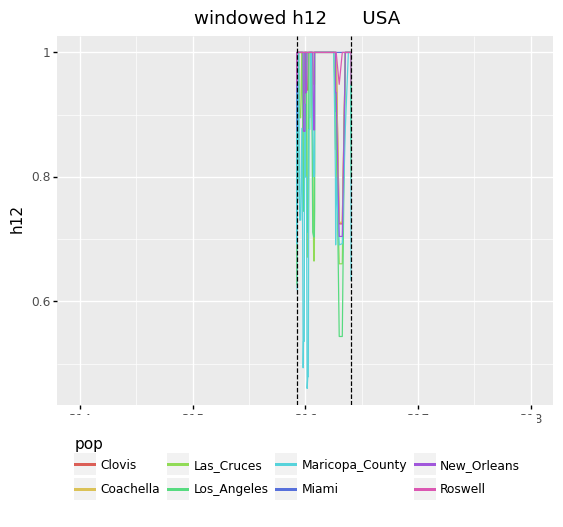

In [114]:
p = ggplot(h12tab_kdr3,aes(x='pos/1e6',y="h12",color="pop")) + \
  geom_line() + geom_vline(xintercept=[l/1e6 for l in locus],linetype="dashed") +\
  xlim([314,318]) +\
  ggtitle("windowed h12      {p1}".format(p1=pop1))  +\
  theme(legend_position="bottom")
ggsave(plot=p, width=300,height=125,units='mm', filename='h12_250bp_kdr3_allvars_region.png', dpi=400)
print(p)